The task in this assignment is to detect the  counterfeit banknotes. The data set is based on [banknote authentication Data Set ](https://archive.ics.uci.edu/ml/datasets/banknote+authentication#) from UCI Machine Learning repository. The first three columns denote different parameters obtained from the photographs of the banknotes and last colum provides the label. Frankly as the dataset does not have any description I don't know  which labels corresponds to real and which to counterfeited banknotes. let's assume that label one (positive) denotes the clounterfeits. The set  [banknote_authentication.csv](./data/banknote_authentication.csv) can be found in the `data`  directory.

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [63]:
import  matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(8,8)

Please insert you  firstname  and name below:
Kinga Klima

In [64]:
from  sklearn.model_selection import train_test_split
seed = 31287

In [65]:
data = pd.read_csv('data/banknotes_data.csv')

In [66]:
data.head()
data.describe()
data.info()
data_train, data_test = train_test_split(data, test_size=0.2, shuffle=True, stratify=data.loc[:,'counterfeit'], random_state=seed)
data_train
lbls_train = data_train['counterfeit']
lbls_test = data_test['counterfeit']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1166 entries, 0 to 1165
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a0           1166 non-null   float64
 1   a1           1166 non-null   float64
 2   a2           1166 non-null   float64
 3   a3           1166 non-null   float64
 4   counterfeit  1166 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 45.7 KB


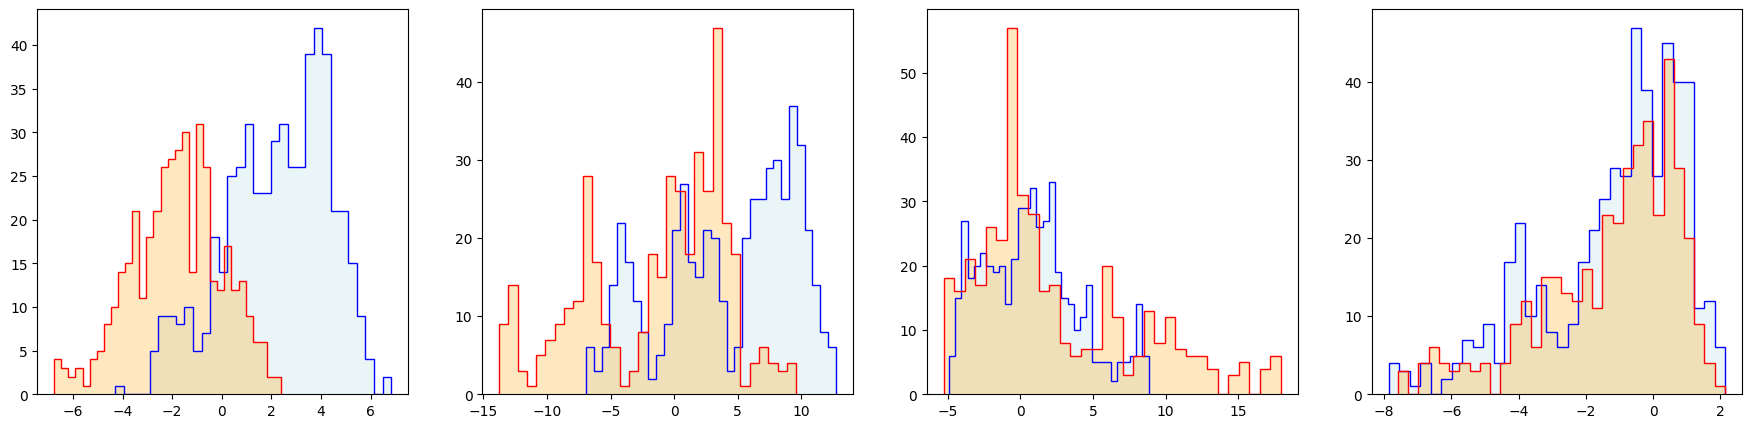

In [67]:
fig, ax = plt.subplots(1,4, figsize=(22,5))
for i in range(4):
    ax[i].hist(data_train[lbls_train==0].iloc[:,i], bins=32, histtype='step', color='blue')
    ax[i].hist(data_train[lbls_train==1].iloc[:,i], bins=32, histtype='step', color='red')
    ax[i].hist(data_train[lbls_train==0].iloc[:,i], bins=32, histtype='bar', color='lightblue', alpha=0.25)
    ax[i].hist(data_train[lbls_train==1].iloc[:,i], bins=32, histtype='bar', color='orange', alpha =0.25)

# Problem 1

Using  the [GaussianNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html) function construct the  Gaussian  Bayes classifier using only one feature. Which feature will you choose? Calculate the confusion matrix (normalized as to show rates), ROC AUC score and plot ROC curve. Do this both for training and validation set. Plot both curves on the same plot.

__Hint__ For calculating metrics and plotting ROC curves you may use functions from scikit-learn: `roc_curve`, `roc_auc_score` and `confusion matrix`. For estimating normal distribution parameters  use `norm.fit` `from scipy.stats`. Use `norm.pdf` for normal probability density function.

Which feature did you choose?

### Feature Selection for Problem 1

Based on the histograms generated earlier, feature 'a0' shows the clearest separation between the two classes.

In [68]:
# Data Preparation for Problem 1
X_train_a0 = data_train[['a0']]
y_train = lbls_train
X_test_a0 = data_test[['a0']]
y_test = lbls_test

In [69]:
# Model Training for Problem 1
gnb_a0 = GaussianNB()
gnb_a0.fit(X_train_a0, y_train)

GaussianNB()

Training ROC AUC Score: 0.9217
Normalized Confusion Matrix (Training Set):


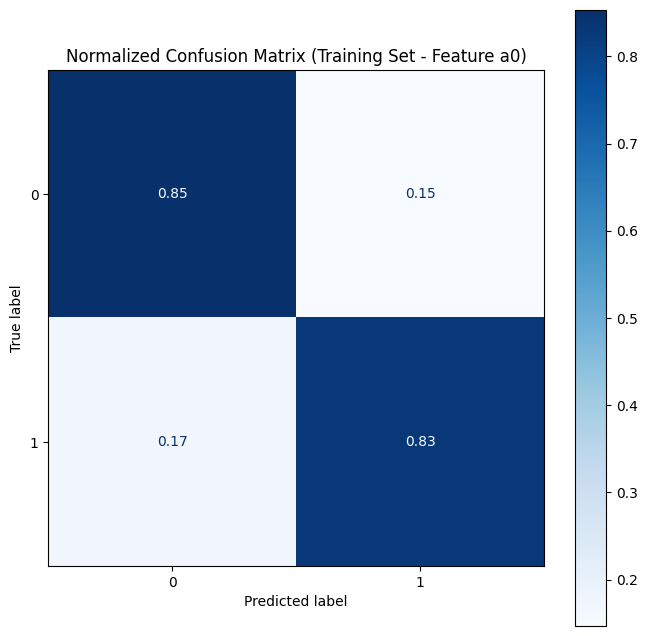

In [70]:
# Training Set Evaluation

y_train_pred_prob_a0 = gnb_a0.predict_proba(X_train_a0)[:, 1]
y_train_pred_a0 = gnb_a0.predict(X_train_a0)

fpr_train_a0, tpr_train_a0, _ = roc_curve(y_train, y_train_pred_prob_a0)
auc_train_a0 = roc_auc_score(y_train, y_train_pred_prob_a0)

cm_train_a0 = confusion_matrix(y_train, y_train_pred_a0, normalize='true')

print(f"Training ROC AUC Score: {auc_train_a0:.4f}")
print("Normalized Confusion Matrix (Training Set):")
disp = ConfusionMatrixDisplay(confusion_matrix=cm_train_a0, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title('Normalized Confusion Matrix (Training Set - Feature a0)')
plt.show()

Test ROC AUC Score: 0.9443
Normalized Confusion Matrix (Test Set):


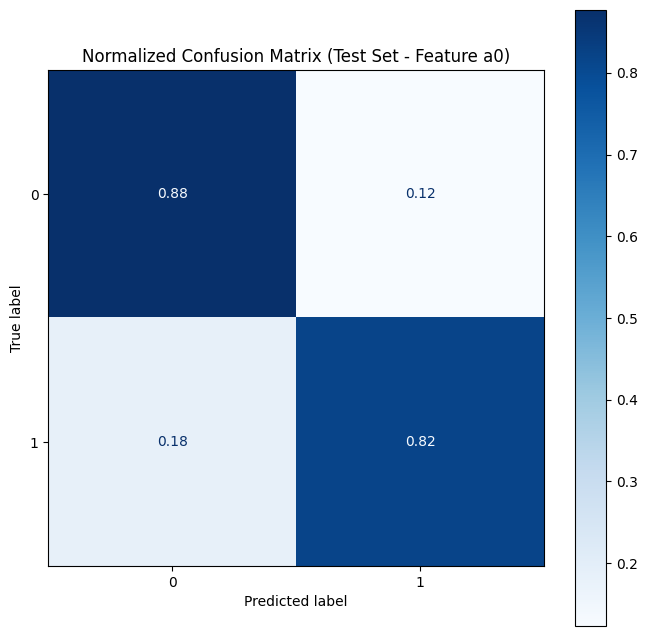

In [71]:
# Test Set Evaluation

y_test_pred_prob_a0 = gnb_a0.predict_proba(X_test_a0)[:, 1]
y_test_pred_a0 = gnb_a0.predict(X_test_a0)

fpr_test_a0, tpr_test_a0, _ = roc_curve(y_test, y_test_pred_prob_a0)
auc_test_a0 = roc_auc_score(y_test, y_test_pred_prob_a0)

cm_test_a0 = confusion_matrix(y_test, y_test_pred_a0, normalize='true')

print(f"Test ROC AUC Score: {auc_test_a0:.4f}")
print("Normalized Confusion Matrix (Test Set):")
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test_a0, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title('Normalized Confusion Matrix (Test Set - Feature a0)')
plt.show()

fprs_test_a0 = fpr_test_a0
tprs_test_a0 = tpr_test_a0
aucs_test_a0 = auc_test_a0

ROC Curve Plot for Problem 1:


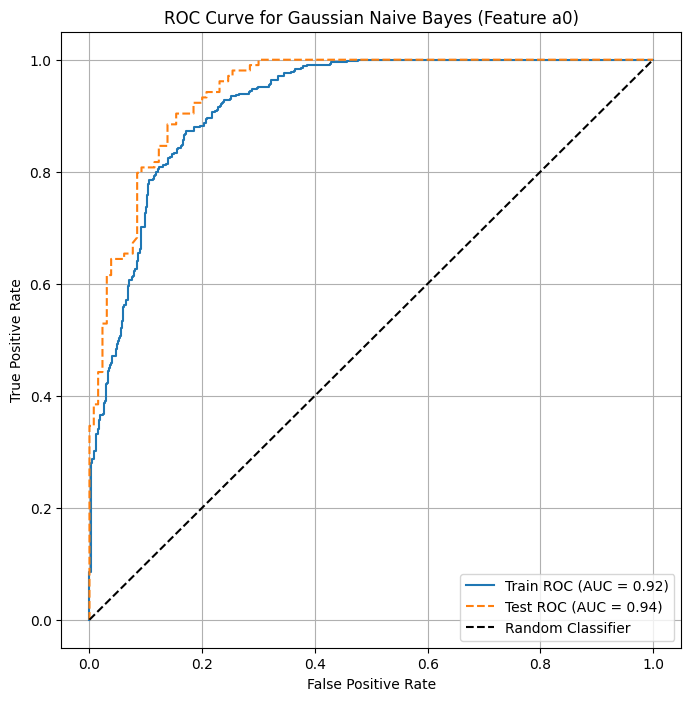

In [72]:
# ROC Curve Plot

print("ROC Curve Plot for Problem 1:")
plt.figure(figsize=(8, 8))
plt.plot(fpr_train_a0, tpr_train_a0, label=f'Train ROC (AUC = {auc_train_a0:.2f})')
plt.plot(fpr_test_a0, tpr_test_a0, label=f'Test ROC (AUC = {auc_test_a0:.2f})', linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Gaussian Naive Bayes (Feature a0)')
plt.legend()
plt.grid(True)
plt.show()

In [41]:
data_train

,a0,a1,a2,a3,counterfeit
711,1.94760,-4.773800,8.52700,-1.866800,0
565,1.42760,8.384700,-2.09950,-1.967700,0
912,-4.28590,8.523400,3.13920,-0.916390,0
64,4.92490,0.689060,0.77344,1.209500,0
871,2.19480,1.378100,1.15820,0.857740,0
...,...,...,...,...,...
47,-2.45610,-4.556600,6.45340,-0.056479,1
1161,1.21380,8.798600,-2.16720,-0.741820,0
174,5.87820,5.940900,-2.85440,-0.608630,0
1119,0.17346,7.869500,0.26876,-3.788300,0


# Problem 2

Same as Problem 1 but now construct Gaussian Naive Bayes using two features. Additionally  compare ROC curve obtained with this and previous  classifier on the test set. What is the improvement of AUC score on the test set?

### Feature Selection for Problem 2

I'll select **'a0'**' and **''a1'** as the two features for constructing this Gaussian Naive Bayes classifier, as they appear to offer the best combined discriminatory power based on visual inspection.

In [73]:
# Data Preparation for Problem 2
X_train_a0a1 = data_train[['a0', 'a1']]
y_train = lbls_train
X_test_a0a1 = data_test[['a0', 'a1']]
y_test = lbls_test

In [74]:
# Model Training for Problem 2
gnb_a0a1 = GaussianNB()
gnb_a0a1.fit(X_train_a0a1, y_train)

GaussianNB()

Training ROC AUC Score: 0.9500
Normalized Confusion Matrix (Training Set):


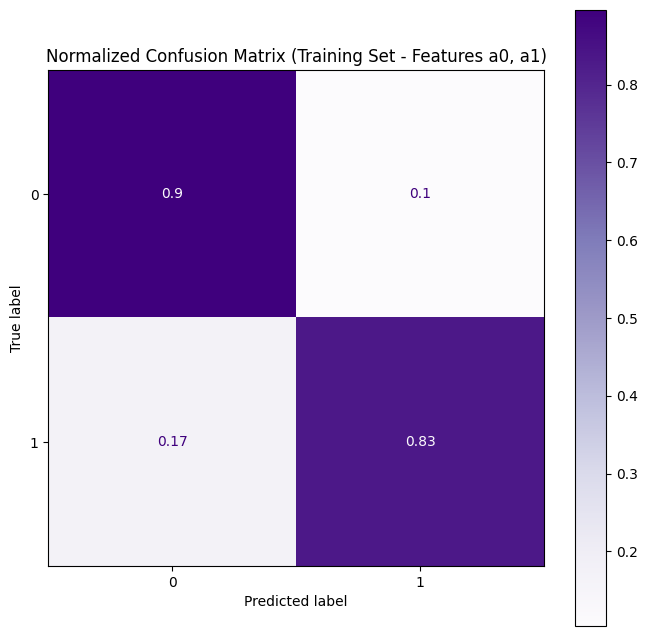

In [75]:
# Training Set Evaluation (Features 'a0' and 'a1')

y_train_pred_prob_a0a1 = gnb_a0a1.predict_proba(X_train_a0a1)[:, 1]
y_train_pred_a0a1 = gnb_a0a1.predict(X_train_a0a1)

fpr_train_a0a1, tpr_train_a0a1, _ = roc_curve(y_train, y_train_pred_prob_a0a1)
auc_train_a0a1 = roc_auc_score(y_train, y_train_pred_prob_a0a1)

cm_train_a0a1 = confusion_matrix(y_train, y_train_pred_a0a1, normalize='true')

print(f"Training ROC AUC Score: {auc_train_a0a1:.4f}")
print("Normalized Confusion Matrix (Training Set):")
disp = ConfusionMatrixDisplay(confusion_matrix=cm_train_a0a1, display_labels=[0, 1])
disp.plot(cmap='Purples')
plt.title('Normalized Confusion Matrix (Training Set - Features a0, a1)')
plt.show()

Test ROC AUC Score: 0.9638
Normalized Confusion Matrix (Test Set):


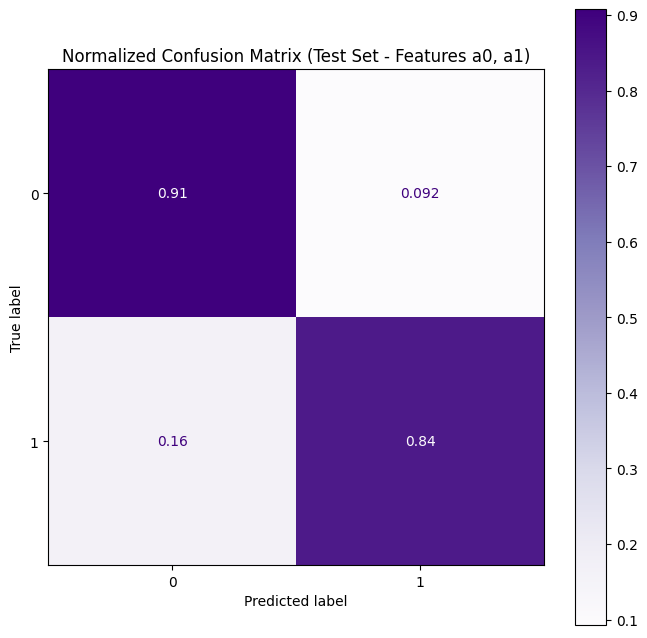

In [76]:
# Test Set Evaluation (Features 'a0' and 'a1')

y_test_pred_prob_a0a1 = gnb_a0a1.predict_proba(X_test_a0a1)[:, 1]
y_test_pred_a0a1 = gnb_a0a1.predict(X_test_a0a1)

fpr_test_a0a1, tpr_test_a0a1, _ = roc_curve(y_test, y_test_pred_prob_a0a1)
auc_test_a0a1 = roc_auc_score(y_test, y_test_pred_prob_a0a1)

cm_test_a0a1 = confusion_matrix(y_test, y_test_pred_a0a1, normalize='true')

print(f"Test ROC AUC Score: {auc_test_a0a1:.4f}")
print("Normalized Confusion Matrix (Test Set):")
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test_a0a1, display_labels=[0, 1])
disp.plot(cmap='Purples')
plt.title('Normalized Confusion Matrix (Test Set - Features a0, a1)')
plt.show()

fprs_test_a0a1 = fpr_test_a0a1
tprs_test_a0a1 = tpr_test_a0a1
aucs_test_a0a1 = auc_test_a0a1

ROC Curve Plot for Problem 2:


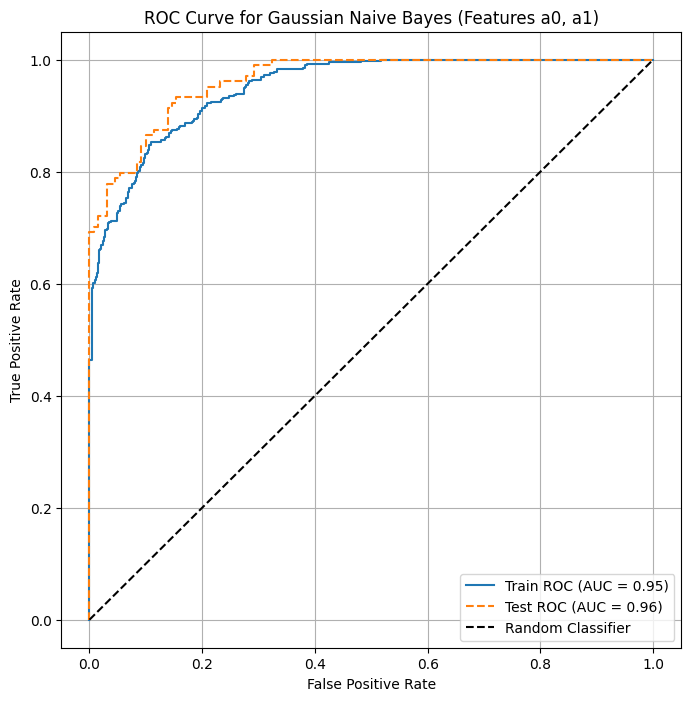

In [77]:
# ROC Curve Plot

print("ROC Curve Plot for Problem 2:")
plt.figure(figsize=(8, 8))
plt.plot(fpr_train_a0a1, tpr_train_a0a1, label=f'Train ROC (AUC = {auc_train_a0a1:.2f})')
plt.plot(fpr_test_a0a1, tpr_test_a0a1, label=f'Test ROC (AUC = {auc_test_a0a1:.2f})', linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Gaussian Naive Bayes (Features a0, a1)')
plt.legend()
plt.grid(True)
plt.show()

# Problem 3

Same as Problem 2 but now implement Gaussian Naive Bayes using all features. Show confusion matrix only for test set. Compare all three ROC curves on the test set, same with AUC score.

In [78]:
# Data Preparation for Problem 3 (All Features)
X_train_all = data_train[['a0', 'a1', 'a2', 'a3']]
y_train = lbls_train
X_test_all = data_test[['a0', 'a1', 'a2', 'a3']]
y_test = lbls_test

In [79]:
# Model Training for Problem 3 (All Features)
gnb_all = GaussianNB()
gnb_all.fit(X_train_all, y_train)

GaussianNB()

Training ROC AUC Score: 0.9348
Normalized Confusion Matrix (Training Set):


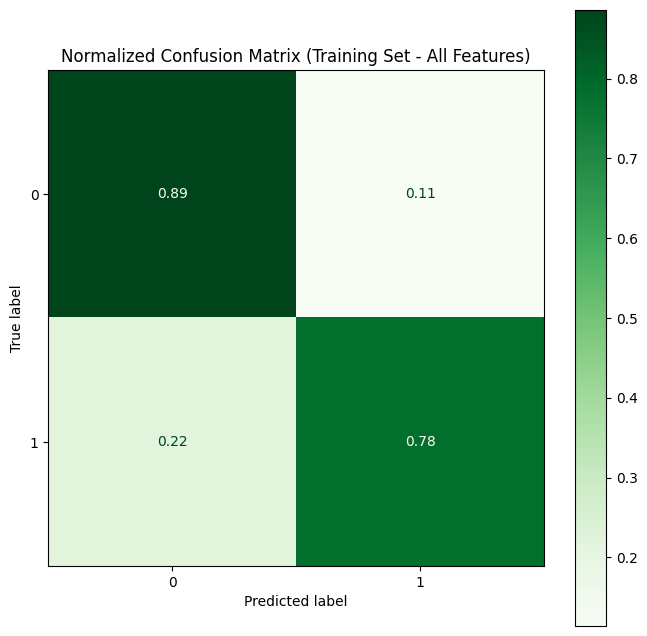

In [80]:
# Training Set Evaluation (All Features)

y_train_pred_prob_all = gnb_all.predict_proba(X_train_all)[:, 1]
y_train_pred_all = gnb_all.predict(X_train_all)

fpr_train_all, tpr_train_all, _ = roc_curve(y_train, y_train_pred_prob_all)
auc_train_all = roc_auc_score(y_train, y_train_pred_prob_all);

cm_train_all = confusion_matrix(y_train, y_train_pred_all, normalize='true')

print(f"Training ROC AUC Score: {auc_train_all:.4f}")
print("Normalized Confusion Matrix (Training Set):")
disp = ConfusionMatrixDisplay(confusion_matrix=cm_train_all, display_labels=[0, 1])
disp.plot(cmap='Greens')
plt.title('Normalized Confusion Matrix (Training Set - All Features)')
plt.show()

Test ROC AUC Score: 0.9521
Normalized Confusion Matrix (Test Set):


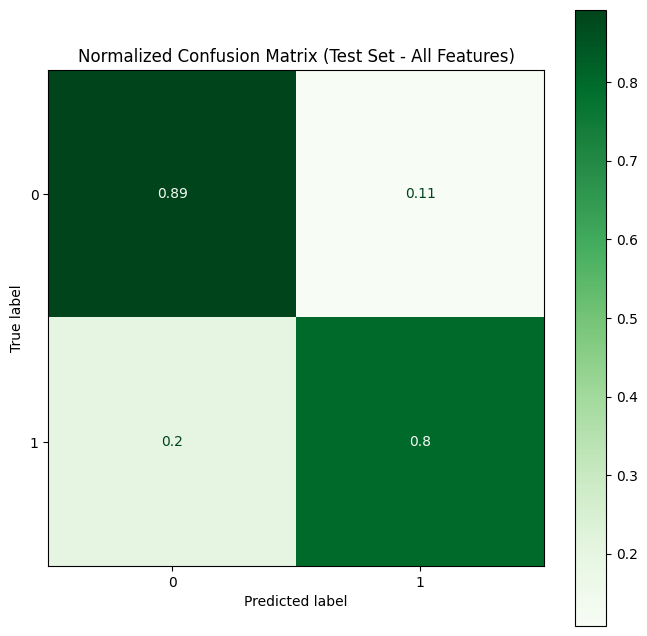

In [81]:
# Test Set Evaluation (All Features)

y_test_pred_prob_all = gnb_all.predict_proba(X_test_all)[:, 1]
y_test_pred_all = gnb_all.predict(X_test_all)

fpr_test_all, tpr_test_all, _ = roc_curve(y_test, y_test_pred_prob_all)
auc_test_all = roc_auc_score(y_test, y_test_pred_prob_all)

cm_test_all = confusion_matrix(y_test, y_test_pred_all, normalize='true')

print(f"Test ROC AUC Score: {auc_test_all:.4f}")
print("Normalized Confusion Matrix (Test Set):")
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test_all, display_labels=[0, 1])
disp.plot(cmap='Greens')
plt.title('Normalized Confusion Matrix (Test Set - All Features)')
plt.show()

fprs_test_all = fpr_test_all
tprs_test_all = tpr_test_all
aucs_test_all = auc_test_all

ROC Curve Plot for Problem 3:


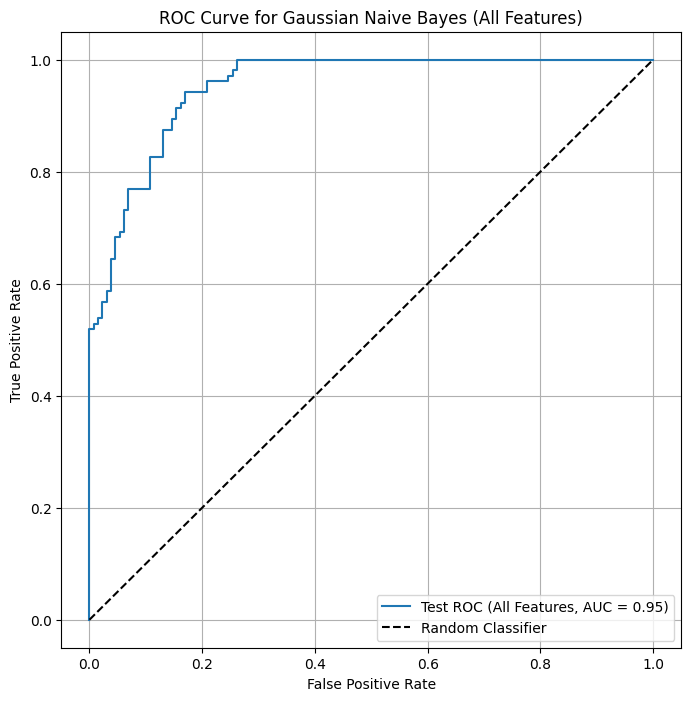

In [82]:
# ROC Curve Plot

print("ROC Curve Plot for Problem 3:")
plt.figure(figsize=(8, 8))
plt.plot(fpr_test_all, tpr_test_all, label=f'Test ROC (All Features, AUC = {auc_test_all:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Gaussian Naive Bayes (All Features)')
plt.legend()
plt.grid(True)
plt.show()

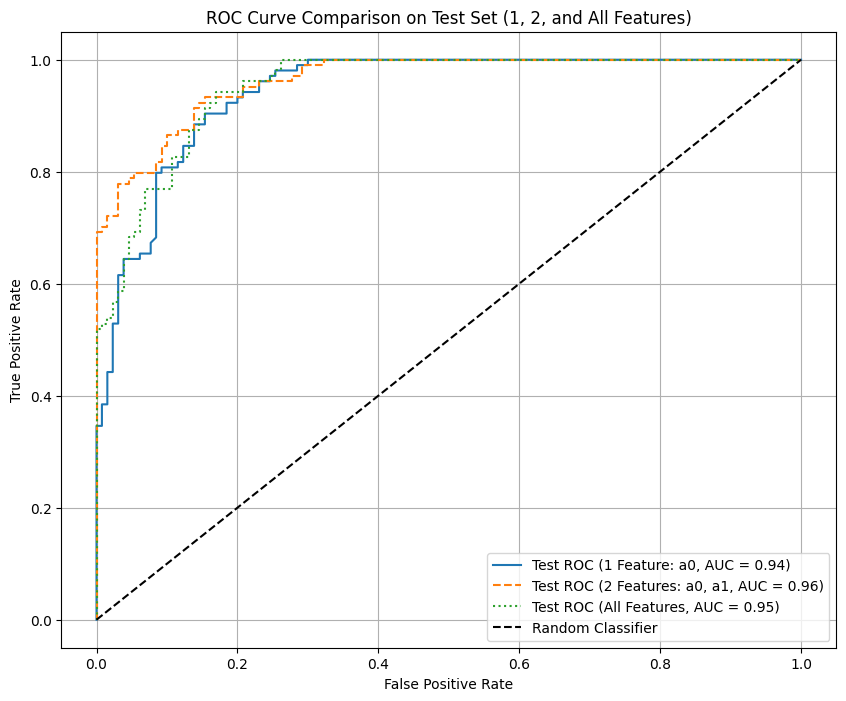


--- AUC Score Improvements ---
Improvement in AUC score from 1 feature (a0) to 2 features (a0, a1): 0.0195
Improvement in AUC score from 2 features (a0, a1) to All features: -0.0117


In [83]:
# Comparison of All Three ROC Curves on Test Set
plt.figure(figsize=(10, 8))
plt.plot(fprs_test_a0, tprs_test_a0, label=f'Test ROC (1 Feature: a0, AUC = {aucs_test_a0:.2f})')
plt.plot(fprs_test_a0a1, tprs_test_a0a1, label=f'Test ROC (2 Features: a0, a1, AUC = {aucs_test_a0a1:.2f})', linestyle='--')
plt.plot(fprs_test_all, tprs_test_all, label=f'Test ROC (All Features, AUC = {aucs_test_all:.2f})', linestyle=':')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison on Test Set (1, 2, and All Features)')
plt.legend()
plt.grid(True)
plt.show()

print("\n--- AUC Score Improvements ---")
auc_improvement_1_to_2 = aucs_test_a0a1 - aucs_test_a0
auc_improvement_2_to_all = aucs_test_all - aucs_test_a0a1
print(f"Improvement in AUC score from 1 feature (a0) to 2 features (a0, a1): {auc_improvement_1_to_2:.4f}")
print(f"Improvement in AUC score from 2 features (a0, a1) to All features: {auc_improvement_2_to_all:.4f}")